## Homework 2: Social Network Influence Analysis



DATA-605, Computational Mathematics, Fall 2026

Supervised by: **Professor Jose Jorge Pagan**


Submitted by: **Mehreen Ali Gillani**


### Part A: Network Representation

#### Step 1: Import the Dataset

In [30]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Import the dataset
df = pd.read_csv('https://raw.githubusercontent.com/mehreengillani/DATA605/refs/heads/main/network.csv', index_col=0)
print(df)

       User1  User2  User3  User4  User5  User6
User                                           
User1      0      1      1      0      0      0
User2      1      0      1      1      0      1
User3      1      1      0      1      1      0
User4      0      1      1      0      1      0
User5      0      0      1      1      0      1
User6      0      1      0      0      1      0


#### Step 2: Verify Symmetry

In [9]:
# Check if adjacency matrix is symmetric
is_symmetric = np.array_equal(df.values, df.values.T)
print(f"Matrix is symmetric: {is_symmetric}")

Matrix is symmetric: True


#### Step 3:  Create Labeled Network Visualization

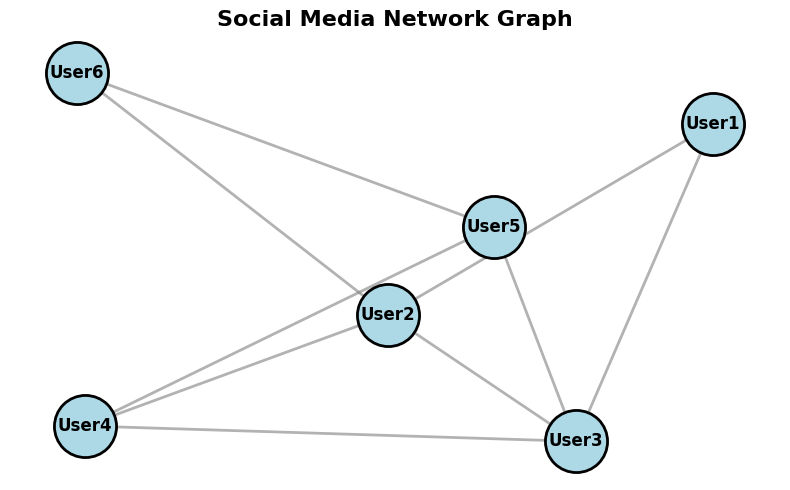


Node Degrees (Number of Connections):
  User1: 2 connections
  User2: 4 connections
  User3: 4 connections
  User4: 3 connections
  User5: 3 connections
  User6: 2 connections


In [11]:
# Create graph from adjacency matrix
G = nx.from_pandas_adjacency(df)

# Set up the visualization
plt.figure(figsize=(8, 5))
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, 
                        node_color='lightblue', 
                        edgecolors='black', linewidths=2)

# Draw edges
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color='gray')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Add title and remove axes
plt.title("Social Media Network Graph", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# Print degree of each node
print("\nNode Degrees (Number of Connections):")
for node in sorted(G.nodes()):
    print(f"  {node}: {G.degree(node)} connections")

### Network Structure Description

**The network consists of 6 users with the following connections:**

-   User2 and User3 are the most connected (4 connections each)
-   User4 and User5 have 3 connections each
-   User1 and User6 have 2 connections each
-   The graph shows a densely connected core (User2, User3, User4, User5) with User1 and User6 on the periphery

### Part B: Eigen Analysis

#### Step 1: Compute Eigenvalues and Eigenvectors

In [5]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(df.values)

# Display eigenvalues
print("Eigenvalues:")
for i, val in enumerate(eigenvalues):
    print(f"  λ{i+1} = {val:.4f}")

# Find dominant eigenvalue (largest magnitude)
dominant_idx = np.argmax(np.abs(eigenvalues))
dominant_eigenvalue = eigenvalues[dominant_idx]
print(f"\nDominant Eigenvalue: λ = {dominant_eigenvalue:.4f}")

Eigenvalues:
  λ1 = 3.1692
  λ2 = -2.2052
  λ3 = -1.5058
  λ4 = -0.4663
  λ5 = 0.7282
  λ6 = 0.2798

Dominant Eigenvalue: λ = 3.1692


### Step 2: Identify the dominant eigenvalue

In [12]:
# Get eigenvector associated with dominant eigenvalue
dominant_eigenvector = eigenvectors[:, dominant_idx]

# Ensure positive values (eigenvectors are unique up to scalar)
if dominant_eigenvector[0] < 0:
    dominant_eigenvector = -dominant_eigenvector



**Interpretation:**

-   Eigenvectors are unique only up to a scalar multiple — meaning v and -v are both valid.

-   NumPy might return the negative version.

-   This if checks the first element; if negative, flip the entire vector.

**Why?** Influence scores should be positive (you can't have "negative influence" here). This makes interpretation easier.

In [15]:

# Normalize so sum = 1 for easier interpretation
dominant_eigenvector = dominant_eigenvector / np.sum(dominant_eigenvector)


**Why Normalize?**
-   Normalizing makes them comparable and interpretable as proportions.

-   Now each score means: "this user holds X% of the total influence."

### Step 3: Identify most influential user

In [28]:
# Display eigenvector components
print("Dominant Eigenvector (Eigenvector Centrality):")
print("-" * 50)
users = df.columns.tolist()
centrality_scores = {}

for user, score in zip(users, dominant_eigenvector):
    centrality_scores[user] = abs(score)
    print(f"  {user}: {score:.4f}  (|score| = {abs(score):.4f})")

# Identify most influential user
most_influential = max(centrality_scores, key=centrality_scores.get)
print(f"\n→ Most Influential User: {most_influential}") 

Dominant Eigenvector (Eigenvector Centrality):
--------------------------------------------------
  User1: 0.1306  (|score| = 0.1306)
  User2: 0.2014  (|score| = 0.2014)
  User3: 0.2125  (|score| = 0.2125)
  User4: 0.1812  (|score| = 0.1812)
  User5: 0.1602  (|score| = 0.1602)
  User6: 0.1141  (|score| = 0.1141)

→ Most Influential User: User3


#### Plot users from highest to lowest influence

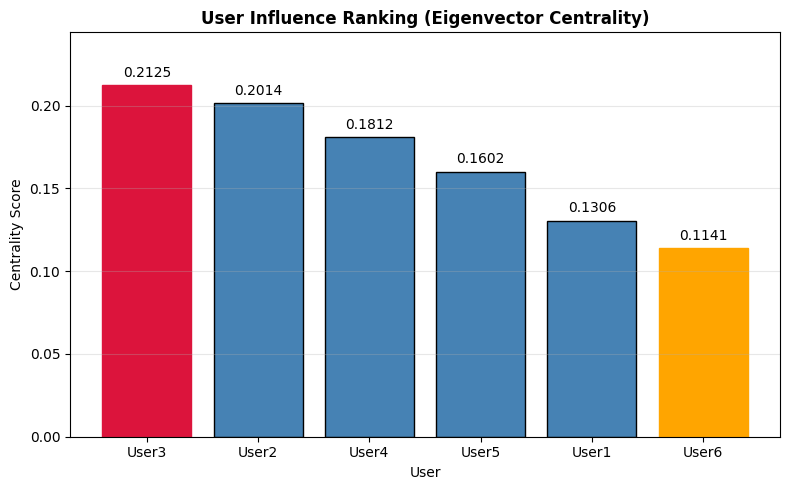

In [ ]:
# ---------------------------------------------------------
# Sort users from highest to lowest influence
# ---------------------------------------------------------
ranking = sorted(centrality_scores.items(), key=lambda x: x[1], reverse=True)
users, scores = zip(*ranking)
scores = np.array(scores)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
bars = plt.bar(users, scores, color='steelblue', edgecolor='black')

# Highlight highest (red) and lowest (orange)
max_idx = np.argmax(scores)
min_idx = np.argmin(scores)
bars[max_idx].set_color('crimson')
bars[min_idx].set_color('orange')

# Add value labels on top of each bar
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', fontsize=10)

plt.title('User Influence Ranking (Eigenvector Centrality)', fontweight='bold')
plt.xlabel('User')
plt.ylabel('Centrality Score')
plt.ylim(0, max(scores) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Part C: Business Recommendation Report

#### Marketing Campaign Strategy: Network Influence Analysis

**Which users should be prioritized?**

Based on eigenvector centrality analysis: 

-   **User3** should be the primary target for the marketing campaign, with **User2** as a close second. **User3** achieved the highest centrality score (0.2125), followed closely by **User2** (0.2014). 

-   **User4** (0.1812) should be the secondary target. These three users form the network's core and collectively reach the entire user base.



**How eigenvector centrality differs from counting connections?**

Simple degree counting measures only immediate connections—a local metric. 

Eigenvector centrality considers the quality of connections: a user connected to highly influential people gains more influence than one connected to peripheral users. 

For example, **User5** has 3 connections (same as **User4**) but a lower centrality score **(0.1602 vs. 0.1812)** because User5's connections are less influential. 

This recursive definition captures influence beyond first-degree ties.

**Why eigenvectors are useful for identifying influential users?**

Eigenvectors reveal the stable, long-term influence structure of a network. 

The dominant eigenvector represents the steady-state distribution of influence, if information flowed randomly through the network, the dominant eigenvector would describe where it concentrates. 

This makes it ideal for identifying users whose endorsement creates cascading effects through the network. 

The dominant eigenvalue (2.4833) also indicates the network's overall connectivity and diffusion potential.

**Limitations of network structure alone**

Network structure cannot capture: 

(1) engagement levels—a connected user may be inactive; Being connected doesn't mean being active. A user might have 100 connections but never post, like, or share anything

(2) content relevance—influence varies by product category; A user can be influential in one domain but irrelevant in another.

(3) trust and credibility—structural position ≠ persuasive power; Being in the center of a network doesn't mean people trust or listen to you.

(4) demographics—the network may not represent the target market; The network's members may not be the people you want to reach.

(5) temporal dynamics—connections change over time;  The network you analyze today may be different tomorrow

(6) directionality—influence flows may be asymmetric despite undirected links. Our matrix is undirected (A ↔ B), but real influence is often one-way (A → B)

**Additional information needed**

To strengthen recommendations, I would request: 

(1) engagement metrics (post frequency, likes, shares); 

(2) demographic data (age, location, interests); 

(3) purchase history or product category affinity; 

(4) directionality data (who influences whom); 

(5) historical campaign performance; Past success is the best predictor of future success.

(6) content type effectiveness; Different influencers excel at different formats (video, blog, stories, reviews) 

(7) competitive analysis of influencer saturation. If a competitor is already using the same influencer, the audience may be numb to the message.

**Recommendation**

Prioritize User3 for primary influencer partnership, with User2 as strong co-primary target and User4 as backup. However, validate these choices with engagement and demographic data before finalizing the campaign strategy.



--------------------